# 04 — Projeção de Risco de OLA/KPI

Este notebook avalia se as previsões de volume P2/P3 do Motor Preditivo podem ser
convertidas em estimativas de violações de OLA/KPI e utilizadas como apoio à decisão
operacional.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import os

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 4.5)
RANDOM_STATE = 42

RAW_PATH = '/content/LWDATASET.xlsx'
SERIE_PATH = '../data/processed/serie_diaria_2025.csv'
GRAFICOS_DIR = '../outputs/graficos'
os.makedirs(GRAFICOS_DIR, exist_ok=True)

df = pd.read_excel(RAW_PATH, sheet_name='Dataset Geral')
df['Aberto'] = pd.to_datetime(df['Aberto'])
df['Resolvido'] = pd.to_datetime(df['Resolvido'])
df['Encerrado'] = pd.to_datetime(df['Encerrado'])
serie = pd.read_csv(SERIE_PATH, parse_dates=['data']).sort_values('data').reset_index(drop=True)
df.shape, serie.shape

((122543, 19), (365, 5))

## Dados e Regra de OLA/KPI

Campos: `Prioridade`, `Aberto`, `Resolvido`, `Encerrado`, `Entrou para KPI?`, `KPI Violado?`.
Apenas P2 (2 - Alta) e P3 (3 - Média). `Entrou para KPI?` e `KPI Violado?` são informações
pós-evento — usadas somente para estatística histórica e validação, nunca como feature de
previsão.

Bandas anuais do dicionário (indicador medido mensalmente):

| Prioridade | OLA quebrado (ano) → % | Volume total (ano) → % |
|---|---|---|
| P2 | <31·31-35·36-39·40-45·46-53·>53 → 150·125·100·75·50·0 | <4585·4585-5388·5389-6168·6169-6252·6253-6336·>6336 → 150·125·100·75·50·0 |
| P3 | <201·201-230·231-263·264-290·291-320·>320 → 150·125·100·75·50·0 | <19489·19489-22116·22117-22524·22525-23892·23893-24276·>24276 → 150·125·100·75·50·0 |

Sem faixa documentada para P1. Rótulos qualitativos (ex.: cores nos gráficos abaixo) são
interpretação do Sentinela, não nomenclatura oficial da Locaweb.

In [ ]:
pri_map = {'2 - Alta': 'P2', '3 - Média': 'P3'}
df_kpi = df[df['Prioridade'].isin(pri_map.keys())].copy()
df_kpi['prio_label'] = df_kpi['Prioridade'].map(pri_map)
len(df_kpi)

57381

## Construção Temporal sem Leakage

Em cada ponto de previsão, somente incidentes cujo resultado já era conhecido antes do
corte temporal são utilizados para estimar as taxas.

In [ ]:
df['timestamp_conhecimento'] = df['Resolvido'].fillna(df['Encerrado'])
df_kpi['timestamp_conhecimento'] = df_kpi['Resolvido'].fillna(df_kpi['Encerrado'])

dur_calc = (df['timestamp_conhecimento'] - df['Aberto']).dt.total_seconds()
match_rate = (dur_calc.round(0) == df['Duração']).mean()
print(f'Consistência timestamp_conhecimento x Duração: {match_rate:.4f}')
print(f'({(dur_calc.round(0) != df["Duração"]).sum()} de {len(df)} registros com divergência residual, sem concentração por prioridade)')

Consistência timestamp_conhecimento x Duração: 0.9959
(497 de 122543 registros com divergência residual, sem concentração por prioridade)


## Taxas Históricas

`P(entra KPI | prioridade)` e `P(viola | entrou KPI, prioridade)`, calculadas apenas com
`timestamp_conhecimento < corte`. Dois métodos causais comparados por erro de previsão do
mês seguinte: **acumulado** (todo o regime recente antes do corte) e **janela_1m** (mês
anterior ao corte).

In [ ]:
def taxa_causal(corte, prio_label, metodo, meses_janela=1):
    pool = df_kpi[(df_kpi['prio_label'] == prio_label) & (df_kpi['timestamp_conhecimento'] < corte)]
    pool_j = pool[pool['Aberto'] >= '2025-09-01'] if metodo == 'acumulado' \
        else pool[pool['Aberto'] >= corte - pd.DateOffset(months=meses_janela)]
    if len(pool_j) == 0:
        return np.nan, np.nan
    te = (pool_j['Entrou para KPI?'] == 'SIM').mean()
    eleg = pool_j[pool_j['Entrou para KPI?'] == 'SIM']
    tv = (eleg['KPI Violado?'] == 'SIM').mean() if len(eleg) > 0 else np.nan
    return te, tv

cortes = [pd.Timestamp('2025-10-01'), pd.Timestamp('2025-11-01'), pd.Timestamp('2025-12-01')]
fins   = [pd.Timestamp('2025-11-01'), pd.Timestamp('2025-12-01'), pd.Timestamp('2026-01-01')]

linhas_metodo = []
for prio in ['P2', 'P3']:
    for corte, fim in zip(cortes, fins):
        real_mes = df_kpi[(df_kpi['prio_label'] == prio) & (df_kpi['Aberto'] >= corte) & (df_kpi['Aberto'] < fim)]
        te_real = (real_mes['Entrou para KPI?'] == 'SIM').mean()
        eleg_real = real_mes[real_mes['Entrou para KPI?'] == 'SIM']
        tv_real = (eleg_real['KPI Violado?'] == 'SIM').mean() if len(eleg_real) > 0 else np.nan
        for metodo in ['acumulado', 'janela_1m']:
            te, tv = taxa_causal(corte, prio, metodo)
            linhas_metodo.append({'Prioridade': prio, 'Método': metodo,
                'erro_entrada': abs(te - te_real) if not np.isnan(te) else np.nan,
                'erro_violacao': abs(tv - tv_real) if not (np.isnan(tv) or np.isnan(tv_real)) else np.nan})

tab_metodo = pd.DataFrame(linhas_metodo)
tab_metodo.groupby('Método')[['erro_entrada', 'erro_violacao']].mean().round(4)

,erro_entrada,erro_violacao
Método,,
acumulado,0.0612,0.0055
janela_1m,0.0506,0.0060


**Escolha:** `taxa_entrada` → janela_1m (menor erro médio; mais reativa ao drift). `taxa_violacao`
→ acumulado (menor erro médio; mais estável com N pequeno). P2: entrada moderadamente
instável. P3: entrada instável (queda de 34,8% para 11,0% entre set e dez). Violações são
eventos raros em ambas (1 a 17 por mês).

## Metodologia de Projeção

```
violações esperadas = volume estimado × taxa histórica de entrada × taxa histórica de violação
```

Volume estimado por dois caminhos, com as mesmas taxas em ambos:

- **ML:** modelos finais do NB02 (ElasticNet para P2; Total D+1 RandomForest × participação
  P3/Total para P3), retreinados a cada corte com dados anteriores, aplicados de forma
  **recursiva** dia a dia até completar o mês — extensão não validada no NB02, que só
  valida D+1 pontual; acumula erro a cada dia projetado.
- **Baseline:** média diária dos ~30 dias anteriores ao corte × dias do mês alvo, sem ML.


In [ ]:
FEATURES_D1 = ['lag_1', 'lag_7', 'media_7d', 'dia_semana_target', 'fim_semana_target']
FEATURES_P2 = ['p2_lag_1', 'p2_lag_7', 'p2_media_7d', 'dia_semana_target', 'fim_semana_target']

def treinar_modelo_total(treino_df):
    d = treino_df.copy()
    d['target_d1'] = d['volume_total'].shift(-1)
    d['lag_1'] = d['volume_total']; d['lag_7'] = d['volume_total'].shift(6)
    d['media_7d'] = d['volume_total'].rolling(7).mean()
    d['dia_semana_target'] = d['data'].shift(-1).dt.dayofweek
    d['fim_semana_target'] = d['dia_semana_target'].isin([5, 6]).astype(int)
    d = d.dropna(subset=FEATURES_D1 + ['target_d1'])
    m = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
    m.fit(d[FEATURES_D1], d['target_d1'])
    return m

def treinar_modelo_p2(treino_df):
    d = treino_df.copy()
    d['target_p2_d1'] = d['volume_p2'].shift(-1)
    d['p2_lag_1'] = d['volume_p2']; d['p2_lag_7'] = d['volume_p2'].shift(6)
    d['p2_media_7d'] = d['volume_p2'].rolling(7).mean()
    d['dia_semana_target'] = d['data'].shift(-1).dt.dayofweek
    d['fim_semana_target'] = d['dia_semana_target'].isin([5, 6]).astype(int)
    d = d.dropna(subset=FEATURES_P2 + ['target_p2_d1'])
    m = make_pipeline(StandardScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000))
    m.fit(d[FEATURES_P2], d['target_p2_d1'])
    return m

def forecast_mensal(historico_vol, ultima_data, modelo, n_dias, features):
    hist = historico_vol.copy(); data_atual = ultima_data; preds = []
    for _ in range(n_dias):
        data_alvo = data_atual + pd.Timedelta(days=1)
        X = pd.DataFrame([[hist[-1], hist[-7], np.mean(hist[-7:]), data_alvo.dayofweek,
                            int(data_alvo.dayofweek in [5, 6])]], columns=features)
        pred = max(modelo.predict(X)[0], 0)
        preds.append(pred); hist.append(pred); data_atual = data_alvo
    return sum(preds)

print('ok')

ok


## Backtest Causal

Walk-forward mensal no regime recente. 3 janelas de teste: outubro, novembro, dezembro/2025
(N=3 avaliações independentes por prioridade). Treino sempre com dados anteriores ao corte;
taxas idênticas entre ML e baseline em cada janela.

In [ ]:
METODO_ENTRADA, METODO_VIOLACAO = 'janela_1m', 'acumulado'
n_dias_list = [31, 30, 31]

linhas = []
for corte, fim, n_dias in zip(cortes, fins, n_dias_list):
    treino = serie[serie['data'] < corte].reset_index(drop=True)
    treino_regime = treino[treino['data'] >= '2025-09-01']

    modelo_total = treinar_modelo_total(treino_regime)
    modelo_p2 = treinar_modelo_p2(treino_regime)
    ultima_data = treino['data'].iloc[-1]

    vol_total_ml = forecast_mensal(treino['volume_total'].tolist(), ultima_data, modelo_total, n_dias, FEATURES_D1)
    vol_p2_ml = forecast_mensal(treino['volume_p2'].tolist(), ultima_data, modelo_p2, n_dias, FEATURES_P2)
    ult3 = treino.tail(3)
    participacao_p3 = ult3['volume_p3'].sum() / ult3['volume_total'].sum()
    vol_p3_ml = vol_total_ml * participacao_p3

    ult_mes = treino.tail(30)
    vol_p2_base = ult_mes['volume_p2'].mean() * n_dias
    vol_p3_base = ult_mes['volume_p3'].mean() * n_dias

    real_mes_serie = serie[(serie['data'] >= corte) & (serie['data'] < fim)]
    real_p2, real_p3 = real_mes_serie['volume_p2'].sum(), real_mes_serie['volume_p3'].sum()

    for prio, vol_ml, vol_base, real_vol in [('P2', vol_p2_ml, vol_p2_base, real_p2),
                                               ('P3', vol_p3_ml, vol_p3_base, real_p3)]:
        te, _ = taxa_causal(corte, prio, METODO_ENTRADA)
        _, tv = taxa_causal(corte, prio, METODO_VIOLACAO)
        viol_ml, viol_base = vol_ml * te * tv, vol_base * te * tv

        real_mes_kpi = df_kpi[(df_kpi['prio_label'] == prio) & (df_kpi['Aberto'] >= corte) & (df_kpi['Aberto'] < fim)]
        viol_reais = ((real_mes_kpi['Entrou para KPI?'] == 'SIM') & (real_mes_kpi['KPI Violado?'] == 'SIM')).sum()

        linhas.append({'Prioridade': prio, 'Mês': corte.strftime('%Y-%m'),
            'Volume real': int(real_vol), 'Volume ML': round(vol_ml, 1), 'Volume Baseline': round(vol_base, 1),
            'Violações reais': int(viol_reais), 'Violações ML': round(viol_ml, 2), 'Violações Baseline': round(viol_base, 2),
            'Erro ML': round(abs(viol_ml - viol_reais), 2), 'Erro Baseline': round(abs(viol_base - viol_reais), 2)})

tab = pd.DataFrame(linhas)
tab

,Prioridade,Mês,Volume real,Volume ML,Volume Baseline,Violações reais,Violações ML,Violações Baseline,Erro ML,Erro Baseline
0,P2,2025-10,2703,2171.0,2303.3,2,1.95,2.07,0.05,0.07
1,P3,2025-10,5094,5957.4,5589.3,9,8.17,7.67,0.83,1.33
2,P2,2025-11,3069,2301.1,2656.0,6,1.69,1.95,4.31,4.05
3,P3,2025-11,4467,7675.7,4953.0,15,11.70,7.55,3.30,7.45
4,P2,2025-12,2004,2766.4,3171.3,1,3.05,3.50,2.05,2.50
5,P3,2025-12,9628,5083.8,4615.9,17,7.32,6.65,9.68,10.35


## Comparação ML × Baseline

Mesma regra de KPI e mesmas taxas em cada janela; única diferença é a origem do volume.

In [ ]:
def janelas_melhores(g):
    return (g['Erro ML'] < g['Erro Baseline']).sum()

resumo = tab.groupby('Prioridade').apply(
    lambda g: pd.Series({
        'MAE ML': g['Erro ML'].mean(),
        'MAE Baseline': g['Erro Baseline'].mean(),
        'Ganho vs baseline (%)': 100 * (1 - g['Erro ML'].mean() / g['Erro Baseline'].mean()),
        'Janelas ML melhor': janelas_melhores(g),
        'N janelas': len(g),
    })
).round(3)
resumo

,MAE ML,MAE Baseline,Ganho vs baseline (%),Janelas ML melhor,N janelas
Prioridade,,,,,
P2,2.137,2.207,3.172,2.0,3.0
P3,4.603,6.377,27.810,3.0,3.0


In [ ]:
linhas_dec = []
for corte, fim in zip(cortes, fins):
    real_mes_serie = serie[(serie['data'] >= corte) & (serie['data'] < fim)]
    real_p2, real_p3 = real_mes_serie['volume_p2'].sum(), real_mes_serie['volume_p3'].sum()
    for prio, real_vol in [('P2', real_p2), ('P3', real_p3)]:
        te, _ = taxa_causal(corte, prio, METODO_ENTRADA)
        _, tv = taxa_causal(corte, prio, METODO_VIOLACAO)
        viol_oraculo = real_vol * te * tv
        real_mes_kpi = df_kpi[(df_kpi['prio_label'] == prio) & (df_kpi['Aberto'] >= corte) & (df_kpi['Aberto'] < fim)]
        viol_reais = ((real_mes_kpi['Entrou para KPI?'] == 'SIM') & (real_mes_kpi['KPI Violado?'] == 'SIM')).sum()
        linhas_dec.append({'Prioridade': prio, 'Erro só-taxa': abs(viol_oraculo - viol_reais)})

tab_dec = pd.DataFrame(linhas_dec).groupby('Prioridade')['Erro só-taxa'].mean().round(3)
print('MAE isolando erro de taxa (volume real x taxa, sem erro de forecast):')
print(tab_dec)
print('\nPróximo do MAE ML da tabela acima -> a taxa domina o erro, não o forecast de volume.')

MAE isolando erro de taxa (volume real x taxa, sem erro de forecast):
Prioridade
P2    1.793
P3    4.444
Name: Erro só-taxa, dtype: float64

Próximo do MAE ML da tabela acima -> a taxa domina o erro, não o forecast de volume.


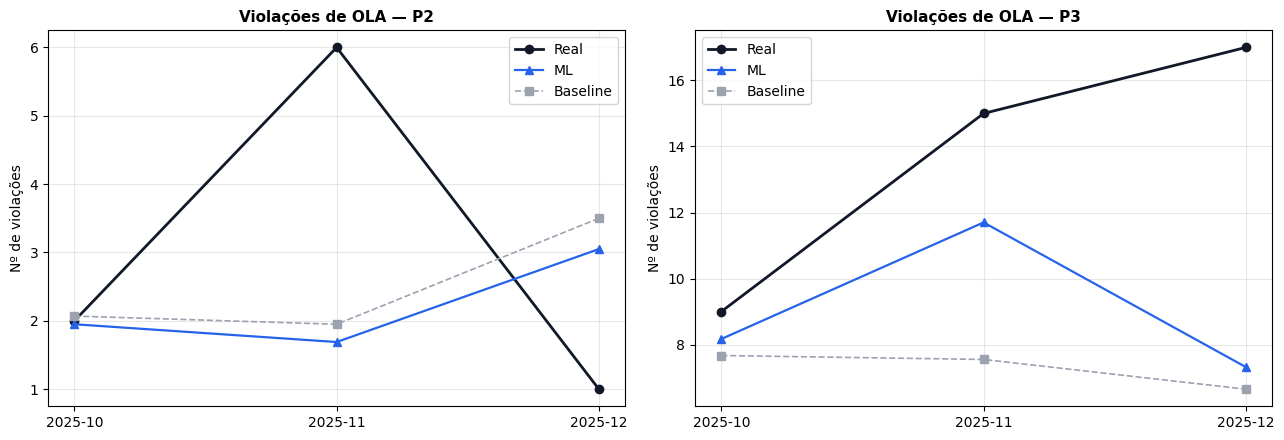

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, prio in zip(axes, ['P2', 'P3']):
    sub = tab[tab['Prioridade'] == prio]
    ax.plot(sub['Mês'], sub['Violações reais'], marker='o', color='#111827', linewidth=2, label='Real')
    ax.plot(sub['Mês'], sub['Violações ML'], marker='^', color='#2563eb', linewidth=1.6, label='ML')
    ax.plot(sub['Mês'], sub['Violações Baseline'], marker='s', color='#9ca3af', linewidth=1.2, linestyle='--', label='Baseline')
    ax.set_title(f'Violações de OLA — {prio}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Nº de violações'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/violacoes_real_vs_projetado_entrega.png', dpi=150)
plt.show()

## Resultado P2

O ganho frente ao baseline foi marginal (~3%), portanto não há evidência suficiente para
afirmar valor incremental consistente do ML na projeção de OLA para P2. ML melhor em 2 das
3 janelas.

**Status: EXPERIMENTAL.**

## Resultado P3

O pipeline alimentado pela previsão de P3 apresentou menor erro que o baseline nas três
janelas avaliadas, com redução agregada próxima de 28%. O resultado é promissor, porém a
amostra de apenas três meses impede uma conclusão robusta.

**Status: EXPERIMENTAL / SINAL PROMISSOR.**

## Impacto nas Faixas de OLA/KPI

Posição do volume e das violações acumuladas no regime recente (set–dez/2025) frente às
bandas anuais do dicionário.

In [ ]:
regime_kpi = df_kpi[df_kpi['Aberto'] >= '2025-09-01']
faixas_volume = {'P2': [(4585,150),(5388,125),(6168,100),(6252,75),(6336,50),(float('inf'),0)],
                  'P3': [(19489,150),(22116,125),(22524,100),(23892,75),(24276,50),(float('inf'),0)]}
faixas_ola = {'P2': [(31,150),(35,125),(39,100),(45,75),(53,50),(float('inf'),0)],
              'P3': [(201,150),(230,125),(263,100),(290,75),(320,50),(float('inf'),0)]}

def classificar(valor, faixas):
    for limite, pct in faixas:
        if valor < limite:
            return pct
    return 0

linhas_bandas = []
for prio in ['P2', 'P3']:
    sub = regime_kpi[regime_kpi['prio_label'] == prio]
    vol = len(sub)
    eleg = sub[sub['Entrou para KPI?'] == 'SIM']
    viol = (eleg['KPI Violado?'] == 'SIM').sum()
    linhas_bandas.append({'Prioridade': prio, 'Volume set-dez': vol, '% banda volume': classificar(vol, faixas_volume[prio]),
                           'Violações set-dez': viol, '% banda OLA': classificar(viol, faixas_ola[prio])})
tab_bandas = pd.DataFrame(linhas_bandas)
tab_bandas

,Prioridade,Volume set-dez,% banda volume,Violações set-dez,% banda OLA
0,P2,10005,0,11,150
1,P3,24598,0,50,150


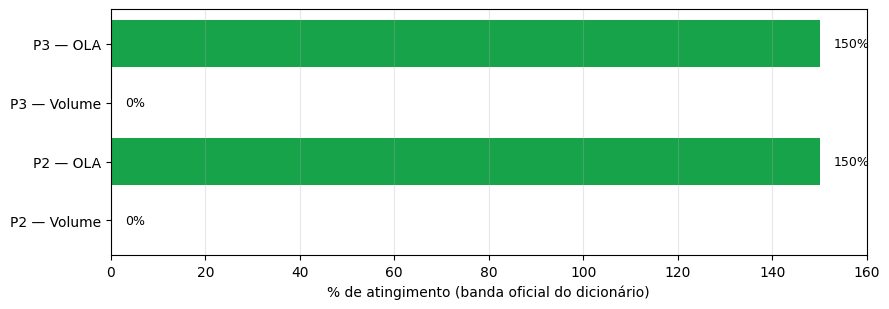

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.2))
labels = ['P2 — Volume', 'P2 — OLA', 'P3 — Volume', 'P3 — OLA']
valores = [tab_bandas.loc[0,'% banda volume'], tab_bandas.loc[0,'% banda OLA'],
           tab_bandas.loc[1,'% banda volume'], tab_bandas.loc[1,'% banda OLA']]
cores = ['#dc2626' if v == 0 else '#f59e0b' if v < 100 else '#16a34a' for v in valores]
ax.barh(labels, valores, color=cores)
ax.set_xlabel('% de atingimento (banda oficial do dicionário)'); ax.set_xlim(0, 160)
for i, v in enumerate(valores):
    ax.text(v + 3, i, f'{v}%', va='center', fontsize=9)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/bandas_kpi_ola_entrega.png', dpi=150)
plt.show()

Nos dados analisados, o crescimento de volume não foi acompanhado por aumento
proporcional das violações de OLA — volume já ocupa a pior banda anual em ambas as
prioridades, enquanto as violações permanecem na melhor banda. Volume e risco de OLA devem
ser monitorados separadamente.

## Limitações

- Apenas 3 meses de avaliação independente (N=3).
- Taxas de entrada em KPI instáveis, sobretudo em P3.
- Violações de OLA são eventos raros (poucas unidades por mês).
- P2 não apresentou ganho relevante do forecast sobre o baseline.
- Projeção mensal depende de forecasts de P2/P3 já classificados como experimentais no NB02.

## Conclusão

A camada OLA/KPI demonstrou viabilidade como extensão analítica do Sentinela. O resultado
foi inconclusivo em P2 e mais promissor em P3, onde o uso do forecast reduziu o erro frente
ao baseline. Devido ao baixo número de meses avaliados e à instabilidade das taxas
históricas, a capacidade permanece ainda como **experimental**.